<a href="https://colab.research.google.com/github/namanarorakarnal2004-blip/Hotel-Booking-Analysis/blob/main/Week3_ML_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving hotel_bookings.csv to hotel_bookings.csv


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('hotel_bookings.csv')
df['children'].fillna(0, inplace=True)
df['agent'].fillna(0, inplace=True)
df['company'].fillna(0, inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['total_guests'] = df['adults'] + df['children'] + df['babies']

print("Ready! ✅", df.shape)

Ready! ✅ (119390, 34)


/tmp/ipykernel_659/372454683.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['children'].fillna(0, inplace=True)
/tmp/ipykernel_659/372454683.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.meth

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Features select karo
features = ['lead_time', 'total_nights', 'total_guests',
            'previous_cancellations', 'booking_changes',
            'adr', 'days_in_waiting_list']

X = df[features]
y = df['is_canceled']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (95512, 7)
Test size: (23878, 7)


In [4]:
# Logistic Regression Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Results
print("Accuracy:", round(accuracy_score(y_test, y_pred)*100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 69.42 %

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.90      0.79     14907
           1       0.68      0.36      0.47      8971

    accuracy                           0.69     23878
   macro avg       0.69      0.63      0.63     23878
weighted avg       0.69      0.69      0.67     23878



In [5]:
from sklearn.metrics import roc_auc_score, roc_curve

# ROC-AUC Score
y_prob = model.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", round(auc, 4))

# ROC Curve Plot
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(8,5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {round(auc,2)}')
plt.plot([0,1],[0,1], 'r--')
plt.title('ROC-AUC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

ROC-AUC Score: 0.7346


NameError: name 'plt' is not defined

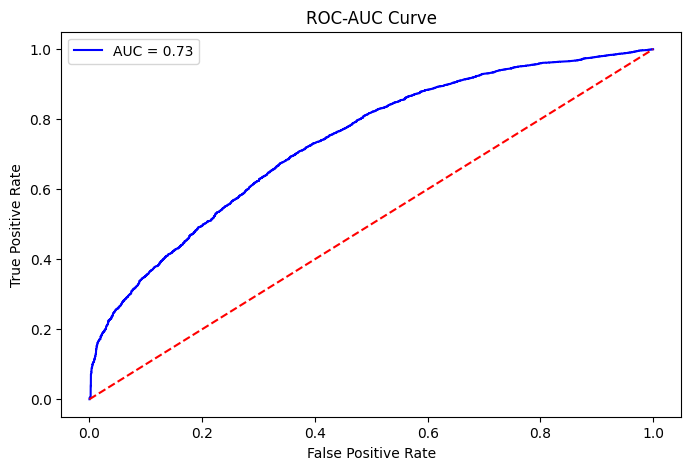

In [6]:
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(8,5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {round(auc,2)}')
plt.plot([0,1],[0,1], 'r--')
plt.title('ROC-AUC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()